# Pipeline: подготовка данных для сегментации клиентов санатория

**Цель ноутбука:** пройти полный путь от `silver.csv` до матрицы признаков `X_scaled`,
готовой для передачи в алгоритм кластеризации.

**Выход:** `df_for_model_cluster` (436 492 гостя × 13 признаков) + `X_scaled` (numpy array).

**Этапы:**
1. Загрузка и EDA
2. Фильтрация (только известные гости)
3. Признаки ДО схлопывания: nights, season, children, booking_group_size
4. Схлопывание: один заезд = одна строка
5. Очистка: служебные тарифы, nights=0 / >90
6. Инжиниринг признаков
7. Отбор признаков → df_model
8. Агрегация до уровня гостя → df_for_model_cluster
9. Импутация + log1p
10. Preprocessing Pipeline (ColumnTransformer) → X_scaled
11. Финальная проверка


## 1. Импорты и настройки

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re                                                       # для регулярных выражений в маппинге тарифов
import joblib                                                   # для сохранения обученных моделей на диск
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering     # основная и иерархическая кластеризация
from sklearn.mixture import GaussianMixture                     # вероятностная кластеризация (GMM)
from sklearn.metrics import (
    silhouette_score,            # средняя «чёткость» разделения кластеров
    silhouette_samples,          # то же, но для каждого объекта отдельно
    calinski_harabasz_score,     # соотношение межкластерного / внутрикластерного разброса
    davies_bouldin_score,        # средняя похожесть кластера на ближайшего соседа (меньше = лучше)
)
from sklearn.decomposition import PCA                           # сжатие данных для визуализации

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
plt.rcParams['figure.dpi'] = 100
print("Импорты OK")

Импорты OK


In [2]:
# ════════════════════════════════════════════════════════════════════════════
# ГЛОБАЛЬНЫЕ КОНСТАНТЫ
# ════════════════════════════════════════════════════════════════════════════
#
# Зачем выносить «магические числа» в константы?
# Если написать "10" в 5 местах кода — при изменении нужно найти все 5.
# Константа меняется в одном месте, и все места обновляются автоматически.
# ════════════════════════════════════════════════════════════════════════════

MAX_FAMILY_SIZE   = 10       # Порог «маленькая группа» для распространения children
                             # <= 10 человек = семья/пара: состав однородный
                             # >  10          = корпоратив: состав неоднородный, не распространяем

MAX_NIGHTS        = 90       # Максимально допустимая длительность пребывания (ночей)
                             # > 90 = либо ошибка ввода, либо долгосрочная аренда (нетипично)

AGE_SENTINEL      = 999      # Код «возраст не заполнен» в системе бронирования
MAX_AGE           = 100      # Выше 100 лет — явная ошибка ввода (в данных был max=976)

SILHOUETTE_SAMPLE = 50_000   # Число гостей для выборочного расчёта Silhouette Score
                             # Полный расчёт O(n^2): при 436к гостях — 190 млрд операций.
                             # Выборка 50к даёт точность +-0.005 за разумное время.

KMEANS_N_INIT     = 10   # число случайных инициализаций KMeans
                         # 20 (текущее) — дорого для разведочного перебоႈа k=2..10

K_MIN, K_MAX      = 2, 11    # Диапазон k для перебора: range(K_MIN, K_MAX) = 2..10

RANDOM_STATE      = 42       # Фиксируем случайность. Один seed = одинаковый результат.
                             # 42 — традиция ML-сообщества (отсылка к Дугласу Адамсу)

print("OK: константы определены")

OK: константы определены


## 2. Загрузка данных и EDA

`silver.csv` — 565 816 строк, 24 колонки, уровень обработки silver.

In [3]:
df = pd.read_csv('../silver.csv')
print(f"Загружено: {df.shape[0]:,} строк × {df.shape[1]} колонок")
df.head(3)

Загружено: 565,816 строк × 24 колонок


,Unnamed: 0,created_dt,check_in_dt,check_out_dt,activity_dt,is_valid,tariff,discount,composition,grp,grp_norm,room_type,currency,guest_id,guest_last_name,citizenship,gender,guest_age,prev_stays,rooms,places,extra_places,children,adults
0,0,2020-12-01,2021-01-30 14:00:00,2021-02-01 12:00:00,2021-02-01 12:00:00,0,Все Включено 2021,25.0,NaN,923 160,923160,К -Комфорт,Руб.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
1,1,2020-12-01,2020-12-15 14:00:00,2020-12-22 12:00:00,2020-12-22 12:00:00,1,Открытый Юг/Доступный Юг от 7 суток 2020г.,NaN,NaN,923 196,923196,К-VS - VS-Комфорт,Руб.,1370402.0,Санкин,РОССИЯ,Мужской,61.0,1.0,NaN,1.0,NaN,NaN,NaN
2,2,2020-12-01,2021-01-30 14:00:00,2021-02-04 12:00:00,2021-02-04 12:00:00,0,Все Включено 2021,25.0,NaN,923 143,923143,К+- Комфорт+,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN


In [4]:
# Сводная таблица: тип, уникальных значений, % пропусков
eda = pd.DataFrame({
    'dtype'    : df.dtypes.astype(str),
    'unique'   : df.nunique(),
    'null_%'   : (df.isna().mean() * 100).round(1),
}).reset_index().rename(columns={'index': 'column'})
print(f"is_valid_for_rfm распределение: {df['is_valid'].value_counts().to_dict()}")
print()
print(eda.to_string(index=False))

is_valid_for_rfm распределение: {1: 521143, 0: 44673}

         column   dtype  unique  null_%
     Unnamed: 0   int64  565816     0.0
     created_dt     str    2163     0.0
    check_in_dt     str    6589     0.0
   check_out_dt     str    3799     0.0
    activity_dt     str    3799     0.0
       is_valid   int64       2     0.0
         tariff     str     634     0.0
       discount float64      66    84.1
    composition     str      28    59.7
            grp     str  144064     0.0
       grp_norm   int64  144064     0.0
      room_type     str      24     0.0
       currency     str       1     3.1
       guest_id float64  447267     7.9
guest_last_name     str  147597     7.9
    citizenship     str      40    23.5
         gender     str       2    23.4
      guest_age float64     270    31.9
     prev_stays float64      74    32.2
          rooms float64      28    95.0
         places float64      44    21.9
   extra_places float64      25    80.5
       children float64  

In [5]:
# Конвертация дат
for col in ['created_dt', 'check_in_dt', 'check_out_dt', 'activity_dt']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print("Диапазон заездов:")
print(f"  check_in_dt:  {df['check_in_dt'].min().date()} → {df['check_in_dt'].max().date()}")
print(f"  check_out_dt: {df['check_out_dt'].min().date()} → {df['check_out_dt'].max().date()}")

Диапазон заездов:
  check_in_dt:  2019-01-01 → 2025-10-30
  check_out_dt: 2019-11-27 → 2029-10-07


## 3. Фильтрация: только известные гости (`is_valid_for_rfm == 1`)

Анонимные гости (is_valid=0, 44 673 строки) — без guest_id.
Их нельзя персонализировать, поэтому для **кластеризации** не используем.
Для прогноза спроса (Модель 2) они пойдут обратно.

In [6]:
n_total = len(df)
df = df[df['is_valid'] == 1].copy()

print(f"До фильтра:  {n_total:,} строк")
print(f"После:       {len(df):,} строк  ({len(df)/n_total*100:.1f}%)")
print(f"Уникальных гостей:  {df['guest_id'].nunique():,}")
print(f"Уникальных заездов: {df['grp_norm'].nunique():,}")

До фильтра:  565,816 строк
После:       521,143 строк  (92.1%)
Уникальных гостей:  447,267
Уникальных заездов: 142,703


In [7]:
# ── Фильтр ковидного периода ────────────────────────────────────────────────
# 2020–2021 — аномальное поведение: закрытые санатории, нетипичные паттерны.
# ПЕРЕКЛЮЧАТЕЛЬ: True = все данные 2019–2025, False = только 2022–2025
USE_FULL_HISTORY = False

if not USE_FULL_HISTORY:
    n_before = len(df)
    df = df[df['check_in_dt'] >= '2022-01-01'].copy()
    print(f"Фильтр: {n_before:,} → {len(df):,} строк (исключено {n_before - len(df):,} до 2022)")
else:
    print("USE_FULL_HISTORY=True: используем все данные 2019–2025")

Фильтр: 521,143 → 375,188 строк (исключено 145,955 до 2022)


## 4. Признаки ДО схлопывания

`nights` и `season` считаются по каждой тарифной строке — это единственный момент,
когда у нас есть отдельные периоды с точными датами.
`children` распространяется по бронированию до схлопывания — иначе 9% вместо 27% семей.

In [8]:
# ── 4.1 nights ────────────────────────────────────────────────────────────
# normalize() убирает время → считаем чистые ночи
df['nights'] = (
    df['check_out_dt'].dt.normalize() - df['check_in_dt'].dt.normalize()
).dt.days.clip(lower=0)

print(f"nights: min={df['nights'].min()}, max={df['nights'].max()}, "
      f"median={df['nights'].median()}")

nights: min=0, max=2024, median=6.0


In [9]:
# ── 4.2 season ────────────────────────────────────────────────────────────
def _get_season(month):
    if month in [12, 1, 2]: return 'зима'
    if month in [3, 4, 5]:  return 'весна'
    if month in [6, 7, 8]:  return 'лето'
    return 'осень'

df['season'] = df['check_in_dt'].dt.month.map(_get_season)
print("Распределение по сезонам:")
print(df['season'].value_counts().to_string())

Распределение по сезонам:
season
лето     112503
весна    100394
зима      84645
осень     77646


In [10]:
# ── 4.3 Распространение children по бронированию ДО схлопывания ──────────
#
# Проблема: adults/children — атрибут НОМЕРА, записан только в одной строке.
#   Фимина (1829): children=2  → данные здесь, она «владелец» состава номера
#   Фимин  (1828): children=NaN → он в том же номере, но у него NaN
#
# Без исправления: только 9% гостей с has_children=1 (занижено в 3 раза!)
# После:          ~27% — реалистичная доля гостей с детьми
#
# Решение: transform('max') внутри grp_norm для малых групп (<= MAX_FAMILY_SIZE чел.).
#
# Логика порога MAX_FAMILY_SIZE:
#   Семья 4 чел.: если у одного children=2, у всех должно быть тоже.
#   Корпоратив 50 чел.: внутри могут быть и с детьми, и без — не распространяем.

grp_size   = df.groupby('grp_norm')['guest_id'].transform('nunique')
small_mask = grp_size <= MAX_FAMILY_SIZE

df.loc[small_mask, 'children'] = (
    df[small_mask]
    .groupby('grp_norm')['children']
    .transform('max')              # если хоть у кого-то children>0 — передаём всем в группе
)

n_with_children = (df['children'] > 0).sum()
print(f"Строк с children > 0: {n_with_children:,}  (до исправления было ~39,449)")

Строк с children > 0: 107,306  (до исправления было ~39,449)


## 5. Схлопывание: один (grp_norm, guest_id) = одна строка

### Зачем

Один гость может иметь несколько строк в рамках одного заезда (смена тарифа, продление).
Это технический артефакт — `groupby(grp_norm, guest_id)` схлопывает их в одну строку.

**Важно:** гости из одной группы (семья, корпоратив) — **разные** `guest_id`,
они остаются отдельными строками после группировки.

### Правила агрегации

| Поле | Агрегация | Обоснование |
|---|---|---|
| `check_in_dt` | min | Начало заезда |
| `check_out_dt` | max | Конец заезда |
| `nights` | sum | Сумма всех тарифных периодов |
| `tariff`, `room_type` | первый ненулевой | Основной тариф/номер |
| `guest_age`, `gender` | первый ненулевой | Атрибут гостя (исправлено: было `first`) |
| `discount` | mean | Средняя скидка по периодам |
| `prev_stays` | max | Все строки одинаковы (из CRM) |

In [11]:
_first_nonnull = lambda x: x.dropna().iloc[0] if x.notna().any() else np.nan

df_deduped = (
    df.groupby(['grp_norm', 'guest_id'], as_index=False)
    .agg(
        created_dt   = ('created_dt',   'min'),
        check_in_dt  = ('check_in_dt',  'min'),
        check_out_dt = ('check_out_dt', 'max'),
        activity_dt  = ('activity_dt',  'max'),
        nights       = ('nights',       'sum'),
        season       = ('season',       lambda x: x.mode().iloc[0] if x.notna().any() else 'unknown'),
        tariff       = ('tariff',       lambda x: x.dropna().iloc[0]
                                        if x.notna().any() else None),
        room_type    = ('room_type',    lambda x: x.dropna().iloc[0]
                                        if x.notna().any() else None),
        children     = ('children',     'max'),
        adults       = ('adults',       'max'),
        places       = ('places',       'max'),
        guest_age    = ('guest_age',    _first_nonnull),
        gender       = ('gender',       _first_nonnull),
        discount     = ('discount',     'mean'),
        prev_stays   = ('prev_stays',   'max'),
    )
)

# booking_group_size: сколько уникальных гостей в одном бронировании
# Это поведенческий признак: соло=1, пара=2, семья=3-4, корпоратив=10+
# Считаем ЗДЕСЬ — после схлопывания тарифных дублей, но ДО агрегации по гостям
df_deduped['booking_group_size'] = (
    df_deduped.groupby('grp_norm')['guest_id'].transform('nunique')
)

print(f"Строк до схлопывания:    {len(df):,}")
print(f"Строк после (заездов):   {len(df_deduped):,}")
print(f"Схлопнуто тарифных дублей: {len(df) - len(df_deduped):,}")
print(f"\nbooking_group_size распределение (топ-10):")
print(df_deduped['booking_group_size'].value_counts().head(10).to_string())


Строк до схлопывания:    375,188
Строк после (заездов):   372,327
Схлопнуто тарифных дублей: 2,861

booking_group_size распределение (топ-10):
booking_group_size
2      76396
3      68847
4      46744
1      16504
5      12430
200     9000
100     8600
6       6018
7       3360
50      3100


## 6. Очистка: служебные тарифы и аномальные nights

### Удаляем из df_deduped:
1. **Служебные тарифы** (`Служебный`, `СОТРУДНИКИ`, `Сотрудник`) — сотрудники, не гости
2. **Административные** (`НЕ СЕЛИТЬ`) — технические записи
3. **nights == 0** — заселение и выезд в один день, не полноценный заезд
4. **nights > 90** — аномалии данных (max=367 у «Новогоднего тура» — ошибка дат)

In [12]:
n0 = len(df_deduped)

# ── Служебные тарифы ──────────────────────────────────────────────────────
# Сотрудники и административные записи — не реальные клиенты.
# str.contains() ищет любое из слов через | (ИЛИ), case=False = без учёта регистра.
# ~ инвертирует маску: оставляем только строки БЕЗ совпадения.
service_mask = df_deduped['tariff'].str.contains(
    r'Служебный|СОТРУДНИКИ|Сотрудник|НЕ СЕЛИТЬ',
    case=False, na=False
)
df_deduped = df_deduped[~service_mask].copy()
print(f"Удалено служебных/административных: {n0 - len(df_deduped):,}")

# ── Аномальные nights ─────────────────────────────────────────────────────
# nights == 0: заезд и выезд в один день — не настоящее проживание
# nights > MAX_NIGHTS: ошибка ввода или долгосрочная аренда (нетипично для санатория)
df_clean = df_deduped[
    (df_deduped['nights'] > 0) & (df_deduped['nights'] <= MAX_NIGHTS)
].copy()

print(f"Удалено nights == 0:           {(df_deduped['nights'] == 0).sum():,}")
print(f"Удалено nights > {MAX_NIGHTS}: {(df_deduped['nights'] > MAX_NIGHTS).sum():,}")
print(f"\ndf_clean: {len(df_clean):,} строк (заездов)")

Удалено служебных/административных: 25,330
Удалено nights == 0:           142
Удалено nights > 90: 15

df_clean: 346,840 строк (заездов)


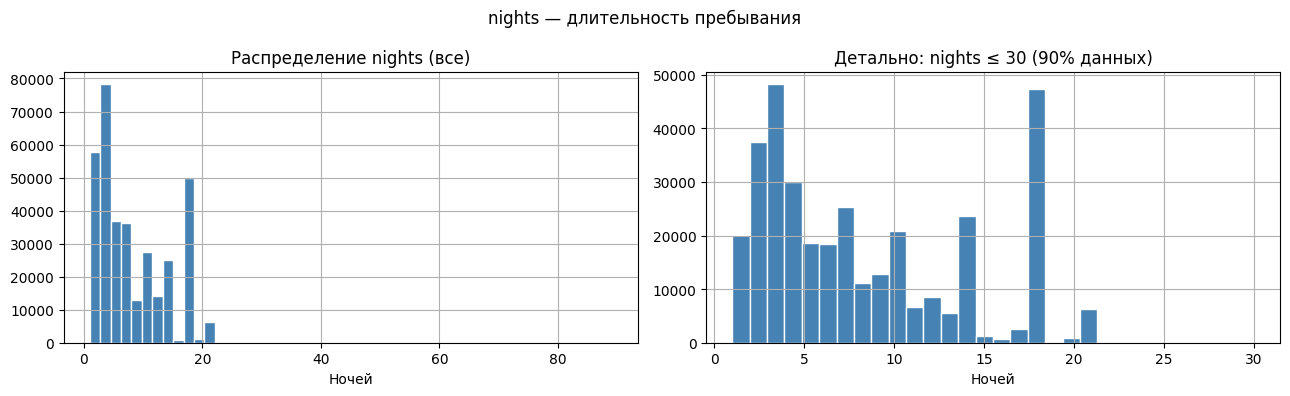

count    346840.0
mean          8.1
std           5.9
min           1.0
25%           3.0
50%           7.0
75%          13.0
max          89.0
Name: nights, dtype: float64


In [13]:
# Быстрая проверка распределения nights
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df_clean['nights'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Распределение nights (все)')
axes[0].set_xlabel('Ночей')

df_clean[df_clean['nights'] <= 30]['nights'].hist(
    bins=30, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Детально: nights ≤ 30 (90% данных)')
axes[1].set_xlabel('Ночей')

plt.suptitle('nights — длительность пребывания', fontsize=12)
plt.tight_layout()
plt.show()

print(df_clean['nights'].describe().round(1))

## 7. Инжиниринг признаков

Строим 12 признаков, которые войдут в матрицу X.
Каждый признак — маркетинговый сигнал для рекомендатора:
«кому и каким оффером закрыть недозагруженность».

### 7.1 lead_time — горизонт бронирования

Сколько дней прошло от создания брони до заезда.
- **Короткий** (1–14 дней): спонтанные гости → last-minute акции
- **Длинный** (60+ дней): планировщики → early bird офферы

In [14]:
# created_dt берём из df_clean (уже очищенного), а не из оригинального df
# Это важно: df содержит служебные тарифы и аномальные ночи, которые мы уже удалили.
# Если брать created_dt из df — получаем утечку данных из «грязного» контекста.
df_clean['lead_time'] = (
    df_clean['check_in_dt'] - df_clean['created_dt']
).dt.days.clip(lower=0)

print(f"Пропуски lead_time: {df_clean['lead_time'].isna().sum():,}")
print(df_clean['lead_time'].describe().round(1))

Пропуски lead_time: 0
count    346840.0
mean         84.2
std          80.9
min           0.0
25%          21.0
50%          58.0
75%         128.0
max         689.0
Name: lead_time, dtype: float64


### 7.2 guest_age — очистка аномалий

- `999` — заглушка «возраст неизвестен» (не аномалия числа, а код)
- `> 100` — явные ошибки ввода (max=976 в сырых данных)

In [15]:
before = df_clean['guest_age'].isna().sum()

# AGE_SENTINEL=999 — не реальный возраст, а код «не заполнено» в системе бронирования.
# replace() заменяет точное значение 999 на NaN (пропуск данных).
df_clean['guest_age'] = df_clean['guest_age'].replace(AGE_SENTINEL, np.nan)

# Значения выше MAX_AGE=100 — явные ошибки ввода (в данных был max=976 лет!).
# Обнуляем их, чтобы они не искажали распределение.
df_clean.loc[df_clean['guest_age'] > MAX_AGE, 'guest_age'] = np.nan

after = df_clean['guest_age'].isna().sum()
print(f"Пропуски guest_age: {before:,} → {after:,} ({after/len(df_clean)*100:.1f}%)")
print(df_clean['guest_age'].dropna().describe().round(1))

Пропуски guest_age: 102,214 → 102,498 (29.6%)
count    244342.0
mean         38.4
std          22.2
min           1.0
25%          15.0
50%          40.0
75%          56.0
max         100.0
Name: guest_age, dtype: float64


### 7.3 tariff_group — 628 тарифов → 8 групп

**Зачем:** конкретные названия тарифов — слишком детальный уровень для кластеризации.
Группа = ценовой сегмент / канал продаж.

| Группа | Паттерн | Маркетинговый смысл |
|---|---|---|
| льготный/корп | ФСС, Согаз, корпор | B2B, партнёры |
| ультра/all-incl | ультра, все включено | Высокий чек |
| стандарт/оптима | стандарт, оптима | Массовый сегмент |
| лечебный | лечени, санатор | Путёвки, особая аудитория |
| новогодний/банкет | новогодн, банкет | Праздничный сегмент |
| событие/группы | фестивал, сборы, турнир | Организованные группы |
| социальный | школьн, серебрян, студент | Льготные группы |
| акция/спецпредл | акция, аквапарк | Промо |
| other | всё остальное | ~10% |


In [16]:
neft_tariffs = (df_clean[df_clean['tariff'].str.contains('нефтегаз', case=False, na=False)]
               ['tariff']
               .value_counts()
               .head(10))
print(neft_tariffs.to_string())

tariff
Юганскнефтегаз               1897
Сургутнефтегаз                435
Самотлорнефтегаз2025          199
Самотлорнефтегаз              198
Сахалинморнефтегаз-Шельф      123
"РН-Пурнефтегаз"              101
Таас-Юрях Нефтегазодобыча      70
Сахалинморнефтегаз             57
Сибнефтегаз АО                 43
Тюменнефтегаз                  41


In [17]:
# Сравниваем поведение нефтегазовых vs ФСС гостей
neft_mask = df_clean['tariff'].str.contains('нефтегаз', case=False, na=False)
fss_mask = df_clean['tariff'].str.contains('фсс', case=False, na=False)

print("=== Нефтегаз ===")
print(df_clean[neft_mask][['nights', 'booking_group_size']].describe().round(1))

print("\n=== ФСС ===")
print(df_clean[fss_mask][['nights', 'booking_group_size']].describe().round(1))

=== Нефтегаз ===
       nights  booking_group_size
count  3169.0              3169.0
mean     14.2                64.9
std       1.1               102.9
min       2.0                 1.0
25%      14.0                12.0
50%      14.0                30.0
75%      14.0                51.0
max      28.0               351.0

=== ФСС ===
       nights  booking_group_size
count  8093.0              8093.0
mean     16.4                32.6
std       4.7                49.5
min       1.0                 1.0
25%      17.0                 1.0
50%      18.0                10.0
75%      18.0                42.0
max      42.0               205.0


In [18]:
# Правила маппинга: 628 уникальных тарифов → 8 смысловых групп.
# Каждое правило — кортеж (название_группы, регулярное_выражение).
#
# Что такое регулярное выражение (regex)?
#   r'слово1|слово2' означает «содержит хоть одно из этих слов»
#   re.search() ищет совпадение ВНУТРИ строки (не обязательно с начала)

_tariff_rules = [
    ('льготный/корп',     r'фсс|гку|согаз|дирекци|народн|нефтегаз|газпром|юганск|кузбасс|ачинск|нпз|азимут|крок'),
    ('ультра/all-incl',   r'ультра|все включено'),
    ('стандарт/оптима',   r'оптима|стандарт|межсезон|стд'),
    ('новогодний/банкет', r'новогодн|банкет|праздн'),
    ('лечебный',          r'лечени|оздоров|санатор|скл|профмед'),
    ('событие/группы',    r'фестивал|шахмат|шашк|сборы|планета|турнир|выходного дня|первенств|каратэ|юфо|фшр|яцковск'),
    ('социальный',        r'школьн|студент|серебрян|золотая|мечтай|возраст|радость'),
    ('акция/спецпредл',   r'аквапарк|акция|спецпредл|каникул|майский|лазурн|пляжн|доступн|открыт|роза ветров|биглион'),
]

def _map_tariff(t):
    # Маппинг тарифа к одной из 8 групп по ключевым словам.
    # re.search(pattern, string) - ищет совпадение внутри строки.
    # Возвращает Match-объект (truthy) или None (falsy).
    # Порядок правил важен: применяется первое сработавшее.
    if pd.isna(t):
        return 'other'
    t_lower = t.lower()                     # приводим к нижнему регистру один раз
    for group, pattern in _tariff_rules:
        if re.search(pattern, t_lower):     # re импортирован в начале ноутбука
            return group
    return 'other'

df_clean['tariff_group'] = df_clean['tariff'].map(_map_tariff)

coverage = (df_clean['tariff_group'] != 'other').mean()
print(f"Покрытие именованными группами: {coverage*100:.1f}%")
print(df_clean['tariff_group'].value_counts().to_string())

Покрытие именованными группами: 95.1%
tariff_group
ультра/all-incl      144235
льготный/корп         76117
стандарт/оптима       58755
событие/группы        28018
other                 17155
социальный             8991
новогодний/банкет      8633
акция/спецпредл        2880
лечебный               2056


### 7.4 room_group — 24 типа номеров → 5 групп

Категория номера определяет, какой сегмент гостей может закрыть недозагруженность.

In [19]:
def _map_room(r):
    if pd.isna(r): return 'other'
    r = r.lower()
    if any(x in r for x in ['люкс', 'lux', 'suite', 'полулюкс']): return 'люкс'
    if 'комфорт' in r:                                              return 'комфорт'
    if any(x in r for x in ['стандарт', 'стд']):                   return 'стандарт'
    if any(x in r for x in ['апарт', 'берлин']):                   return 'апартаменты'
    return 'other'

df_clean['room_group'] = df_clean['room_type'].map(_map_room)

print(f"room_group распределение:")
print(df_clean['room_group'].value_counts().to_string())

room_group распределение:
room_group
стандарт       208969
комфорт        136684
апартаменты       825
люкс              320
other              42


### 7.5 Числовые и бинарные признаки

| Признак | Тип | Бизнес-смысл |
|---|---|---|
| `discount_rate` | num | Ценовая чувствительность (0–100%) |
| `has_children` | bin | Семейный сегмент → нужны семейные программы |
| `pct_weekend_in` | bin | Weekend-турист (пятница/суббота) |
| `pct_summer` | num | Доля летних визитов гостя (0.0–1.0) — связка с Prophet |
| `pct_autumn` | num | Доля осенних визитов гостя (0.0–1.0) — связка с Prophet |
| `pct_winter` | num | Доля зимних визитов гостя (0.0–1.0) — связка с Prophet |

In [20]:
# ── discount_rate ─────────────────────────────────────────────────────────
# clip(0, 100): убираем отрицательные значения и >100% (ошибки ввода)
# fillna(0): NaN = скидки не было → приравниваем к нулю
df_clean['discount_rate'] = df_clean['discount'].clip(0, 100).fillna(0)

# ── has_children ──────────────────────────────────────────────────────────
# После распространения children (секция 4.3) этот признак корректен.
# (df['children'] > 0) → True/False, .astype(int) → 1/0
df_clean['has_children'] = (df_clean['children'] > 0).astype(int)

# ── pct_weekend_in ─────────────────────────────────────────────────────────
# dt.dayofweek: 0=Пн, 1=Вт, 2=Ср, 3=Чт, 4=Пт, 5=Сб, 6=Вс
#
# Заезд в пятницу (4) или субботу (5) = признак «отдыхающего» визита.
# Используем isin([4, 5]) вместо >= 4, чтобы НЕ включать воскресенье (6) —
# воскресный заезд редок и имеет другой смысл (чаще деловой).
df_clean['pct_weekend_in'] = df_clean['check_in_dt'].dt.dayofweek.isin([4, 5]).astype(int)

# ── Переименование ────────────────────────────────────────────────────────
df_clean = df_clean.rename(columns={'nights': 'stay_duration'})

print("Доли бинарных признаков:")
print(f"  has_children  = {df_clean['has_children'].mean()*100:.1f}%  гостей приезжали с детьми")
print(f"  pct_weekend_in = {df_clean['pct_weekend_in'].mean()*100:.1f}%  заездов в пятницу/субботу")
print(f"  discount_rate > 0: {(df_clean['discount_rate'] > 0).mean()*100:.1f}%  гостей имели скидку")

Доли бинарных признаков:
  has_children  = 30.6%  гостей приезжали с детьми
  pct_weekend_in = 30.6%  заездов в пятницу/субботу
  discount_rate > 0: 15.9%  гостей имели скидку


## 8. Отбор признаков → df_model

### Включены (13 признаков)

| Признак | Тип | Почему |
|---|---|---|
| stay_duration | num | Длительность пребывания |
| lead_time | num | Горизонт бронирования |
| guest_age | num | Возраст |
| prev_stays | num | Лояльность / история по CRM |
| discount_rate | num | Ценовая чувствительность |
| pct_summer | num | Доля летних визитов (июнь-авг) — связка с Prophet: закрыть летний провал |
| pct_autumn | num | Доля осенних визитов (сент-нояб) — связка с Prophet: закрыть осенний провал |
| pct_winter | num | Доля зимних визитов (дек-фев) — связка с Prophet: закрыть зимний провал |
| **booking_group_size** | **num** | **Типичный размер группы заезда: соло=1, пара=2, семья=3-4, корпоратив=10+** |
| tariff_group | cat | Ценовой сегмент |
| room_group | cat | Категория номера |
| gender | cat | Пол |
| has_children | bin | Семейный сегмент |
| pct_weekend_in | bin | Weekend-паттерн |

### Дополнительно вычислен (не в X_NUM)

| Признак | Где | Зачем |
|---|---|---|
| `booking_group_size_max` | df_for_model_cluster | Макс. размер группы — для анализа и матрицы аффинности; в кластеризацию не входит |

### Почему booking_group_size информативен

`grp_norm` — это ID бронирования. К одному бронированию могут быть прикреплены
несколько гостей (семья, пара, корпоратив). Сам `grp_norm` как ID бесполезен,
но **количество уникальных гостей внутри бронирования** несёт маркетинговый смысл:

- Гость с `booking_group_size=1` всегда едет один → вероятно, бизнес-турист
- `booking_group_size=2` + `has_children=0` → скорее пара
- `booking_group_size=4` + `has_children=1` → семья с детьми
- `booking_group_size=15` + `tariff_group='льготный/корп'` → корпоративная группа

### Исключены (с обоснованием)

| Признак | Причина исключения |
|---|---|
| `has_discount` | corr=0.86 с `discount_rate` → двойной вес |
| `is_repeat` | Бинаризация `prev_stays` → меньше информации |
| `n_stays` | corr=0.74 с `prev_stays`; `prev_stays` из CRM полнее |
| `is_partner` | Перекрывается с `tariff_group` (льготный/корп) |
| `citizenship` | 99.9% РОССИЯ → нет дискриминационной силы |
| `currency` | Одно значение |
| `grp_norm` (как ID) | ID сам по себе не признак; извлекли из него `booking_group_size` |
| `month_sin`, `month_cos` | mean(sin/cos) некорректен для угловых величин при агрегации по гостю; заменены на pct_summer/pct_autumn/pct_winter |

In [21]:
ID_COLS  = ['guest_id', 'grp_norm']
X_NUM    = ['stay_duration', 'lead_time', 'guest_age', 'prev_stays',
            'discount_rate', 'pct_summer', 'pct_autumn', 'pct_winter',
            # pct_spring убран: sum(pct_*) = 1.0 — линейная зависимость.
            # pct_spring восстанавливается как 1 - pct_summer - pct_autumn - pct_winter
            'booking_group_size', 'pct_weekend_in']
X_CAT    = ['tariff_group', 'room_group', 'gender']
X_BIN    = ['has_children']
ALL_FEAT = X_NUM + X_CAT + X_BIN + ['pct_spring']  # pct_spring в df_model для агрегации, в модель не входит
# season не включаем: заменён на pct_summer/pct_autumn/pct_winter/pct_spring
# (mean агрегация по визитам даёт более богатое представление сезонности)

# pct_summer / pct_autumn / pct_winter — доля визитов гостя в каждый сезон.
# Считаем здесь на уровне заезда (0 или 1), агрегируем в mean при groupby.
# Это правильный способ: вместо некорректного mean(sin/cos) по углам.
df_clean['pct_summer'] = df_clean['check_in_dt'].dt.month.isin([6, 7, 8]).astype(int)
df_clean['pct_autumn'] = df_clean['check_in_dt'].dt.month.isin([9, 10, 11]).astype(int)
df_clean['pct_winter'] = df_clean['check_in_dt'].dt.month.isin([12, 1, 2]).astype(int)
df_clean['pct_spring'] = df_clean['check_in_dt'].dt.month.isin([3, 4, 5]).astype(int)

df_model = df_clean[ID_COLS + ALL_FEAT].copy()
df_model['age_is_unknown'] = df_model['guest_age'].isna().astype(int)

print(f"df_model: {df_model.shape[0]:,} строк × {df_model.shape[1]} колонок")
print(f"  Числовые  ({len(X_NUM)}): {X_NUM}")
print(f"  Катег.    ({len(X_CAT)}): {X_CAT}")
print(f"  Бинарные  ({len(X_BIN)}): {X_BIN}")
print(f"\nПропуски:")
null_counts = df_model[ALL_FEAT].isna().sum()
print(null_counts[null_counts > 0] if null_counts.any() else "  Пропусков нет")

df_model: 346,840 строк × 18 колонок
  Числовые  (10): ['stay_duration', 'lead_time', 'guest_age', 'prev_stays', 'discount_rate', 'pct_summer', 'pct_autumn', 'pct_winter', 'booking_group_size', 'pct_weekend_in']
  Катег.    (3): ['tariff_group', 'room_group', 'gender']
  Бинарные  (1): ['has_children']

Пропуски:
guest_age     102498
prev_stays    107210
gender         77579
dtype: int64


## 9. Анализ корреляций и распределений (df_model)

Убеждаемся, что в матрице нет сильно коррелированных признаков,
которые давали бы двойной вес одному и тому же сигналу.

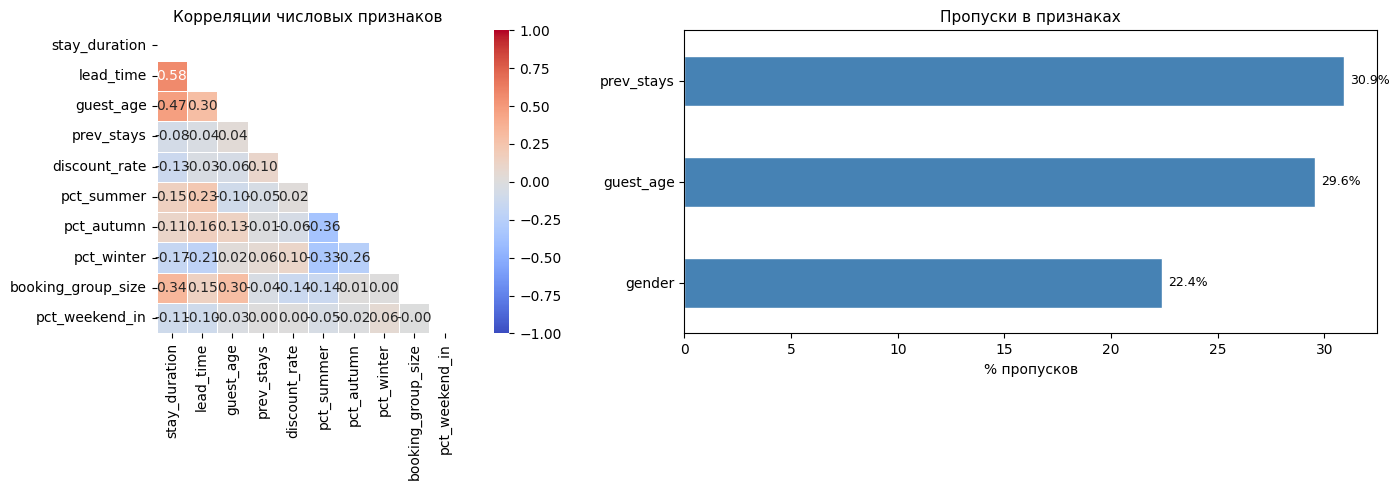

In [22]:
corr = df_model[X_NUM].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=axes[0],
            linewidths=0.5, square=True)
axes[0].set_title('Корреляции числовых признаков', fontsize=11)

# Пропуски
null_pct = (df_model[ALL_FEAT].isna().mean() * 100).sort_values(ascending=True)
null_pct = null_pct[null_pct > 0]
if len(null_pct):
    null_pct.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
    axes[1].set_xlabel('% пропусков')
    axes[1].set_title('Пропуски в признаках', fontsize=11)
    for i, v in enumerate(null_pct):
        axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
else:
    axes[1].text(0.5, 0.5, 'Пропусков нет', ha='center', va='center',
                 transform=axes[1].transAxes, fontsize=14)
    axes[1].set_title('Пропуски в признаках', fontsize=11)

plt.tight_layout()
plt.show()

## 10. Агрегация до уровня гостя → df_for_model_cluster

**Цель:** один гость = одна строка. Сейчас в df_model одна строка = один заезд.
Гость, приезжавший 5 раз, представлен 5 строками.

### Правила агрегации

| Признак | Агрегация | Логика |
|---|---|---|
| stay_duration | mean | Средняя длина заезда |
| lead_time | mean | Средний горизонт |
| guest_age | первый ненулевой | Атрибут гостя (стабильный) |
| prev_stays | max | Накопленная CRM-история |
| discount_rate | mean | Средняя скидка |
| pct_summer | mean | Доля летних визитов (0.0–1.0) |
| pct_autumn | mean | Доля осенних визитов (0.0–1.0) |
| pct_winter | mean | Доля зимних визитов (0.0–1.0) |
| **booking_group_size** | **mean** | **Типичный размер группы по всем заездам** |
| gender | первый ненулевой | Атрибут гостя |
| has_children | max | 1 = хоть раз приезжал с детьми |
| pct_weekend_in | mean | Доля weekend-заездов |
| tariff_group, room_group | mode | Типичный тариф/номер |

In [23]:
# _first_nonnull уже определена в секции 5 (ячейка схлопывания).
# Используем повторно — без переопределения.

num_agg = {
    'stay_duration':      'mean',          # средняя длина заезда по всем визитам
    'lead_time':          'mean',          # средний горизонт бронирования
    'guest_age':          _first_nonnull,  # возраст — стабильный атрибут, берём первый известный
    'prev_stays':         'max',           # CRM-счётчик накапливается → берём максимальное значение
    'discount_rate':      'mean',          # средняя скидка по всем визитам
    # pct_*: доля визитов в каждый сезон — для связки с Prophet
    # Если Prophet предсказал провал в феврале → таргетируем гостей с pct_winter > 0.3
    # Если провал в июле → таргетируем гостей с pct_summer > 0.5 и т.д.
    'pct_summer':         'mean',
    'pct_autumn':         'mean',
    'pct_winter':         'mean',
    'pct_spring':         'mean',  # доля визитов весной (март-май)
    'booking_group_size': 'mean',          # типичный размер группы по всем заездам
    'age_is_unknown':     'max',           # 1 = хотя бы в одном заезде возраст был неизвестен
    'gender':             _first_nonnull,  # пол — стабильный атрибут гостя
    'has_children':       'max',           # 1 = хоть раз приезжал с детьми
    'pct_weekend_in':      'mean',          # доля заездов в пятницу/субботу (0.0..1.0)
}
cat_agg = {
    'tariff_group': lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'other',  # самый частый тариф; guard если все NaN
    'room_group':   lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'other',  # самый частый тип номера; guard если все NaN
}

g = df_model.groupby('guest_id')
df_for_model_cluster = g.agg(num_agg)
df_for_model_cluster[['tariff_group', 'room_group']] = (
    g[['tariff_group', 'room_group']].agg(cat_agg)
)
# booking_group_size_max — не входит в X_NUM, но полезен для анализа сегментов
# и матрицы аффинности: mean=1.5 (обычно парами), max=30 → корпоративный гость.
df_for_model_cluster['booking_group_size_max'] = g['booking_group_size'].max()
# n_stays — метаданные: сколько раз гость приезжал. В признаки X не включается.
df_for_model_cluster['n_stays'] = g['stay_duration'].count()
df_for_model_cluster = df_for_model_cluster.reset_index()

print(f"df_for_model_cluster: {df_for_model_cluster.shape[0]:,} гостей")
print(f"  (было {len(df_model):,} строк-заездов → схлопнуто до уровня гостя)")
print(f"\nbooking_group_size после агрегации:")
print(df_for_model_cluster['booking_group_size'].describe().round(2))
print(f"\nПропуски: {df_for_model_cluster[ALL_FEAT].isna().sum().sum()}")

df_for_model_cluster: 316,783 гостей
  (было 346,840 строк-заездов → схлопнуто до уровня гостя)

booking_group_size после агрегации:
count    316783.00
mean         31.77
std          67.73
min           1.00
25%           2.50
50%           4.00
75%          35.00
max         860.00
Name: booking_group_size, dtype: float64

Пропуски: 277856


In [24]:
# Быстрый взгляд на итоговый датасет
df_for_model_cluster.head()

,guest_id,stay_duration,lead_time,guest_age,prev_stays,discount_rate,pct_summer,pct_autumn,pct_winter,pct_spring,booking_group_size,age_is_unknown,gender,has_children,pct_weekend_in,tariff_group,room_group,booking_group_size_max,n_stays
0,72.0,9.0,26.0,36.0,6.0,0.0,0.0,0.0,0.0,1.0,3.0,0,Мужской,0,0.0,событие/группы,комфорт,3,1
1,134.0,9.0,25.0,41.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0,Женский,0,0.0,событие/группы,комфорт,1,1
2,190.0,10.0,9.0,15.0,NaN,0.0,0.0,0.0,0.0,1.0,59.0,0,Мужской,0,0.0,событие/группы,комфорт,59,1
3,191.0,12.0,5.0,76.0,2.0,0.0,0.0,0.0,0.0,1.0,1.0,0,Мужской,0,0.0,событие/группы,комфорт,1,1
4,263.0,15.0,2.0,69.0,2.0,0.0,0.0,0.0,0.0,1.0,33.0,0,Мужской,0,1.0,событие/группы,стандарт,33,1


### Сезонные паттерны гостей — статистика

> Эта ячейка заполняется после первого запуска.
> Ожидаемые вопросы после запуска:
> - Какой % гостей **никогда** не приезжал летом (pct_summer = 0)?
> - Какой % гостей приезжает **только** летом (pct_summer = 1)?
> - Есть ли гости с высоким pct_summer **и** высоким pct_winter одновременно?
> - Нужна ли нормировка: pct_summer + pct_autumn + pct_winter ≤ 1 (весна = 1 - сумма)?

In [25]:
# ── Сезонные паттерны: базовая статистика ────────────────────────────────
# Заполняется при первом запуске на реальных данных
season_cols = ['pct_summer', 'pct_autumn', 'pct_winter', 'pct_spring']

print("=" * 55)
print("  Сезонные признаки — статистика после агрегации")
print("=" * 55)
print(df_for_model_cluster[season_cols].describe().round(3))

print("\n% гостей с pct_* = 0 (никогда не приезжали в этот сезон):")
for col in season_cols:
    pct_zero = (df_for_model_cluster[col] == 0).mean() * 100
    print(f"  {col}: {pct_zero:.1f}%")

print("\n% гостей с pct_* = 1 (приезжали ТОЛЬКО в этот сезон):")
for col in season_cols:
    pct_one = (df_for_model_cluster[col] == 1).mean() * 100
    print(f"  {col}: {pct_one:.1f}%")


# Проверка: убедимся что линейной зависимости больше нет
pct_cols = ['pct_summer', 'pct_autumn', 'pct_winter']
corr_matrix = df_for_model_cluster[pct_cols].corr()
print("Корреляция сезонных признаков (pct_spring исключён):")
print(corr_matrix.round(3))
print(f"\nСумма трёх признаков (должна != 1.0 для большинства): "
      f"mean={df_for_model_cluster[pct_cols].sum(axis=1).mean():.3f}")

  Сезонные признаки — статистика после агрегации
       pct_summer  pct_autumn  pct_winter  pct_spring
count  316783.000  316783.000  316783.000  316783.000
mean        0.321       0.216       0.189       0.274
std         0.465       0.407       0.388       0.442
min         0.000       0.000       0.000       0.000
25%         0.000       0.000       0.000       0.000
50%         0.000       0.000       0.000       0.000
75%         1.000       0.000       0.000       1.000
max         1.000       1.000       1.000       1.000

% гостей с pct_* = 0 (никогда не приезжали в этот сезон):
  pct_summer: 67.5%
  pct_autumn: 77.8%
  pct_winter: 80.5%
  pct_spring: 71.8%

% гостей с pct_* = 1 (приезжали ТОЛЬКО в этот сезон):
  pct_summer: 31.7%
  pct_autumn: 20.9%
  pct_winter: 18.4%
  pct_spring: 26.7%
Корреляция сезонных признаков (pct_spring исключён):
            pct_summer  pct_autumn  pct_winter
pct_summer       1.000      -0.361      -0.335
pct_autumn      -0.361       1.000      -0.2

## 11. Импутация пропусков + log1p-трансформация

### Импутация

| Признак | Стратегия | Обоснование |
|---|---|---|
| guest_age | median | Нейтральное заполнение (32% пропусков) |
| prev_stays | 0 | NaN = нет в CRM = первичный гость |
| gender | 'unknown' | Пол не удалось определить |

### log1p-трансформация

`prev_stays` (max=648, p99=24) и `lead_time` (max=689, p95=255) имеют экстремальный
правый хвост. При `StandardScaler` большинство значений сжимается у нуля, выбросы
уходят на ~100 сигм — KMeans начинает игнорировать все остальные признаки.

`log1p(x) = log(1+x)` сжимает хвост, сохраняет монотонность и ноль (`log1p(0)=0`).

**Порядок:** импутация → log1p → StandardScaler (в ColumnTransformer).

age_is_unknown: {0: 218514, 1: 98269}
age_is_unknown std: 0.463  (должно быть > 0)
Пропуски после импутации:
stay_duration         0
lead_time             0
guest_age             0
prev_stays            0
discount_rate         0
pct_summer            0
pct_autumn            0
pct_winter            0
booking_group_size    0
pct_weekend_in        0
tariff_group          0
room_group            0
gender                0
has_children          0
pct_spring            0
age_is_unknown        0
dtype: int64
booking_group_size p95=166.0, max до cap=860.0
После cap: max=166.0


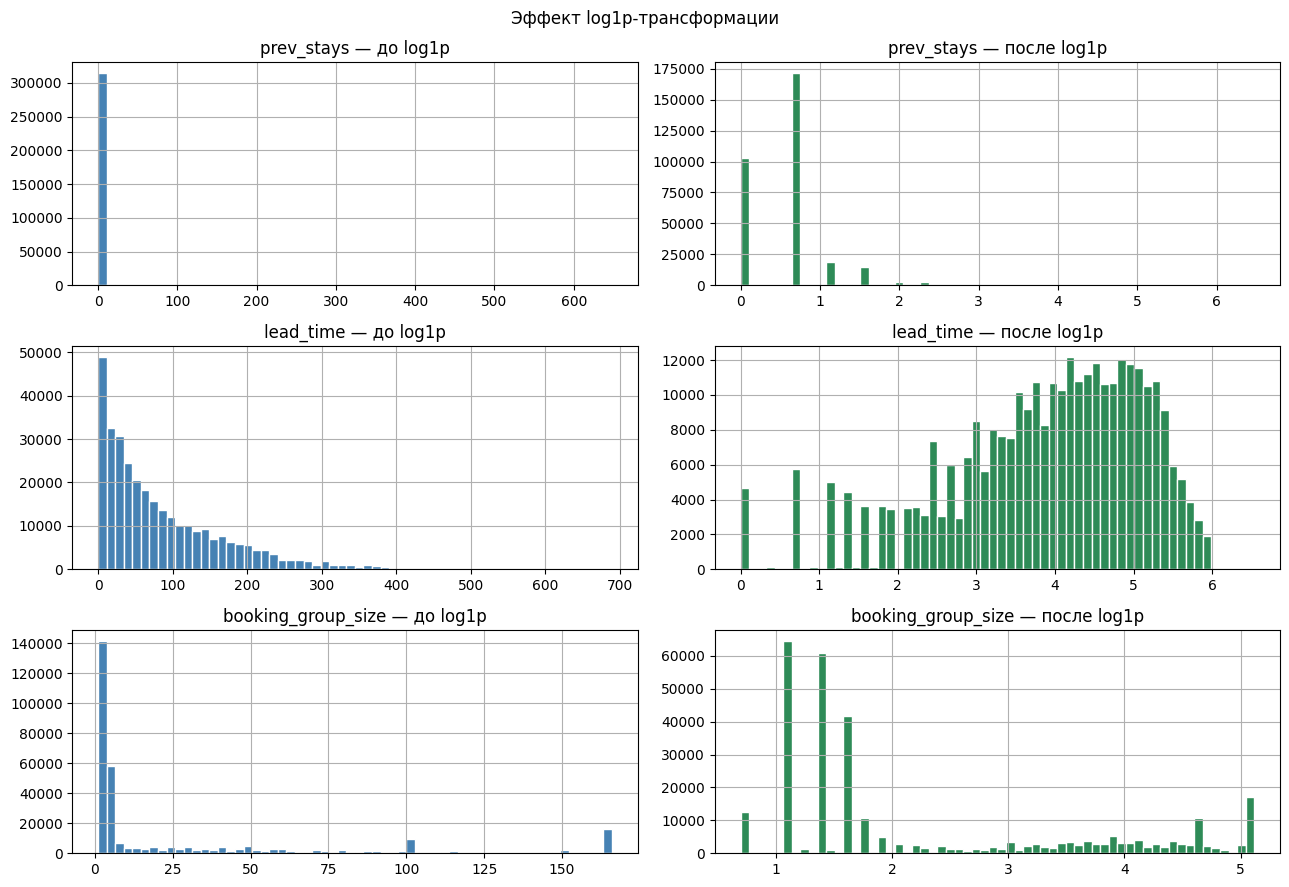


Статистика после log1p:
       prev_stays   lead_time  booking_group_size
count  316783.000  316783.000          316783.000
mean        0.578       3.855               2.296
std         0.515       1.288               1.387
min         0.000       0.000               0.693
25%         0.000       3.135               1.253
50%         0.693       4.078               1.609
75%         0.693       4.852               3.584
max         6.475       6.537               5.118


In [26]:
# ── Проверка age_is_unknown (вычислен в секции 8+10, до fillna) ──────────
print(f"age_is_unknown: {df_for_model_cluster['age_is_unknown'].value_counts().to_dict()}")
print(f"age_is_unknown std: {df_for_model_cluster['age_is_unknown'].std():.3f}  (должно быть > 0)")

# ── Импутация ─────────────────────────────────────────────────────────────
# Стратифицированная импутация: медиана внутри каждой группы тарифов.
# Гости ультра/all-incl и льготный/корп имеют разное возрастное распределение.
age_by_tariff = df_for_model_cluster.groupby('tariff_group')['guest_age'].transform('median')
df_for_model_cluster['guest_age'] = df_for_model_cluster['guest_age'].fillna(age_by_tariff)
# Остаточные пропуски (если в tariff_group все NaN) — глобальной медианой:
df_for_model_cluster['guest_age'] = df_for_model_cluster['guest_age'].fillna(
    df_for_model_cluster['guest_age'].median()
)
df_for_model_cluster['prev_stays'] = df_for_model_cluster['prev_stays'].fillna(0)
df_for_model_cluster['gender']     = df_for_model_cluster['gender'].fillna('unknown')

print("Пропуски после импутации:")
print(df_for_model_cluster[ALL_FEAT + ['age_is_unknown']].isna().sum())

# ── log1p ─────────────────────────────────────────────────────────────────
# ── Cap booking_group_size на p95 ───────────────────────────────────────────
# Группы 350–1135 чел. — статистические выбросы (нефтегаз, ФСС).
# Cap на p95 сохраняет смысл "большая группа", убирает экстремальный хвост.
p95_bgs = df_for_model_cluster['booking_group_size'].quantile(0.95)
print(f"booking_group_size p95={p95_bgs:.1f}, max до cap={df_for_model_cluster['booking_group_size'].max():.1f}")
df_for_model_cluster['booking_group_size'] = df_for_model_cluster['booking_group_size'].clip(upper=p95_bgs)
print(f"После cap: max={df_for_model_cluster['booking_group_size'].max():.1f}")

LOG_COLS = ['prev_stays', 'lead_time', 'booking_group_size']
# booking_group_size: mean по гостю, max=1135 — такой же тяжёлый хвост как prev_stays

fig, axes = plt.subplots(3, 2, figsize=(13, 9))
for i, col in enumerate(LOG_COLS):
    df_for_model_cluster[col].hist(bins=60, ax=axes[i][0],
                                   color='steelblue', edgecolor='white')
    axes[i][0].set_title(f'{col} — до log1p')
    np.log1p(df_for_model_cluster[col]).hist(bins=60, ax=axes[i][1],
                                              color='seagreen', edgecolor='white')
    axes[i][1].set_title(f'{col} — после log1p')

plt.suptitle('Эффект log1p-трансформации', fontsize=12)
plt.tight_layout()
plt.show()

for col in LOG_COLS:
    df_for_model_cluster[col] = np.log1p(df_for_model_cluster[col])

print("\nСтатистика после log1p:")
print(df_for_model_cluster[LOG_COLS].describe().round(3))


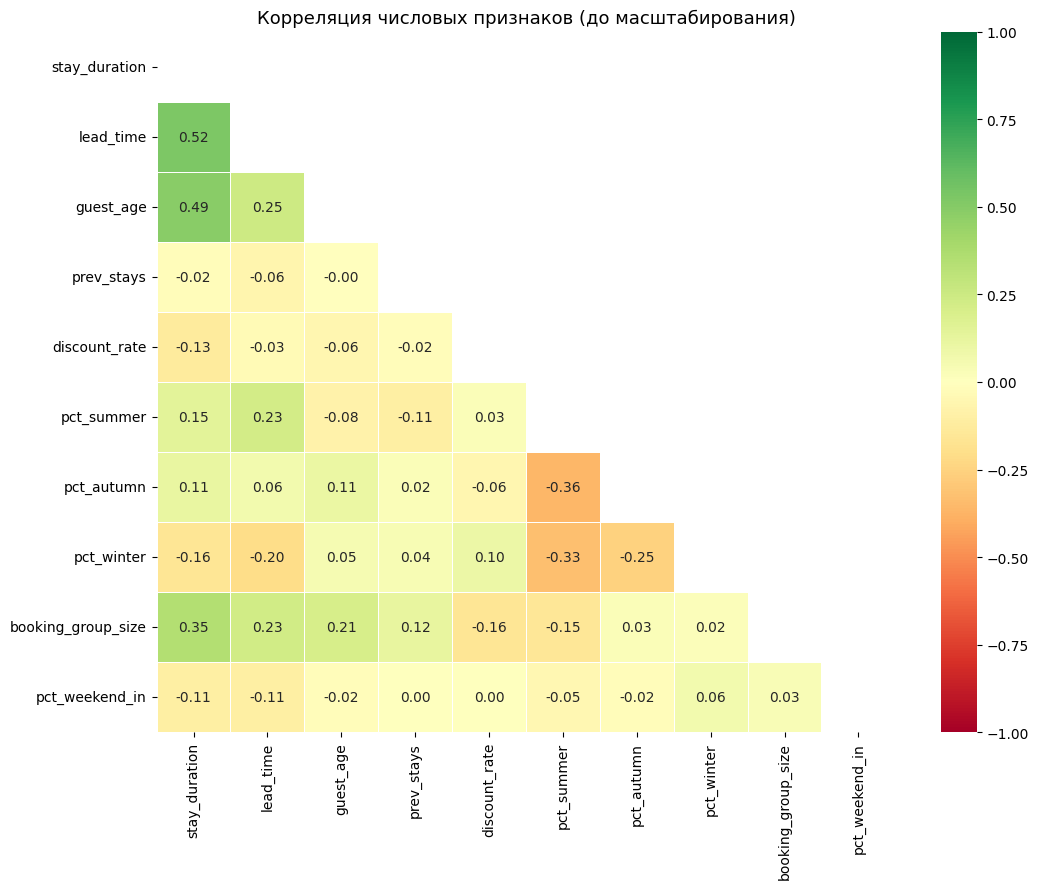


Сильные корреляции (|r| > 0.4):
  lead_time <-> stay_duration: r = 0.524
  guest_age <-> stay_duration: r = 0.487


In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# ── Корреляционная матрица числовых признаков ──────────────────────────────
num_cols_for_corr = [
    'stay_duration', 'lead_time', 'guest_age', 'prev_stays',
    'discount_rate', 'pct_summer', 'pct_autumn', 'pct_winter',
    'booking_group_size', 'pct_weekend_in'
]

corr = df_for_model_cluster[num_cols_for_corr].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))  # только нижний треугольник
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Корреляция числовых признаков (до масштабирования)', fontsize=13)
plt.tight_layout()
plt.show()

# Вывод сильных корреляций (|r| > 0.4) для анализа
print("\nСильные корреляции (|r| > 0.4):")
for i in range(len(corr.columns)):
    for j in range(i):
        r = corr.iloc[i, j]
        if abs(r) > 0.4:
            print(f"  {corr.columns[i]} <-> {corr.columns[j]}: r = {r:.3f}")

## 12. Распределения и баланс классов перед масштабированием

Проверяем:
- Числовые: нет ли доминирующих аномалий после log1p
- Категориальные: не доминирует ли одна категория (>80% → низкая информативность после OHE)
- Бинарные: не слишком ли редкий признак

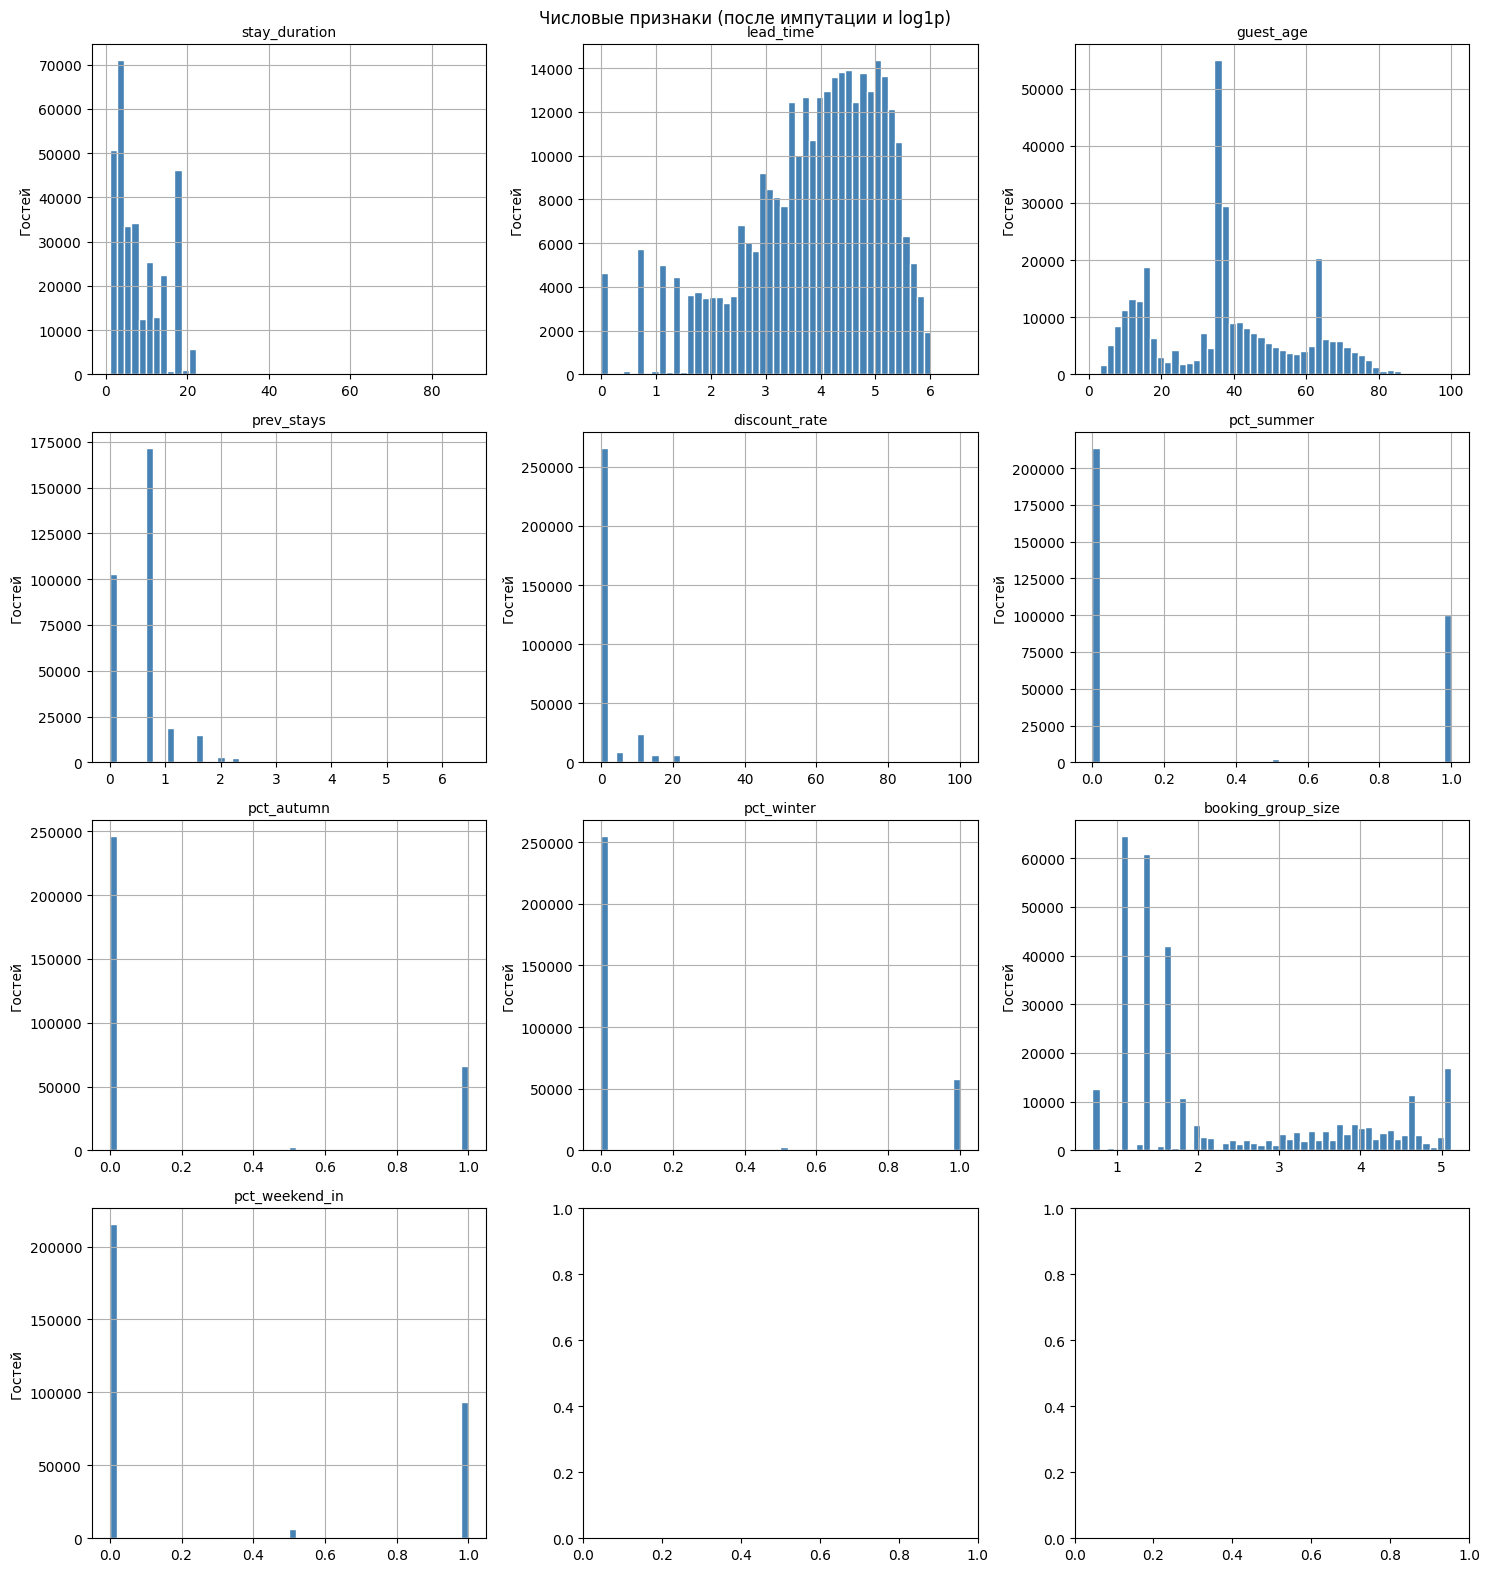

In [28]:
# Числовые распределения
fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes_flat = axes.flatten()
for i, col in enumerate(X_NUM):
    df_for_model_cluster[col].hist(bins=50, ax=axes_flat[i],
                                   color='steelblue', edgecolor='white')
    axes_flat[i].set_title(col, fontsize=10)
    axes_flat[i].set_ylabel('Гостей')
plt.suptitle('Числовые признаки (после импутации и log1p)', fontsize=12)
plt.tight_layout()
plt.show()

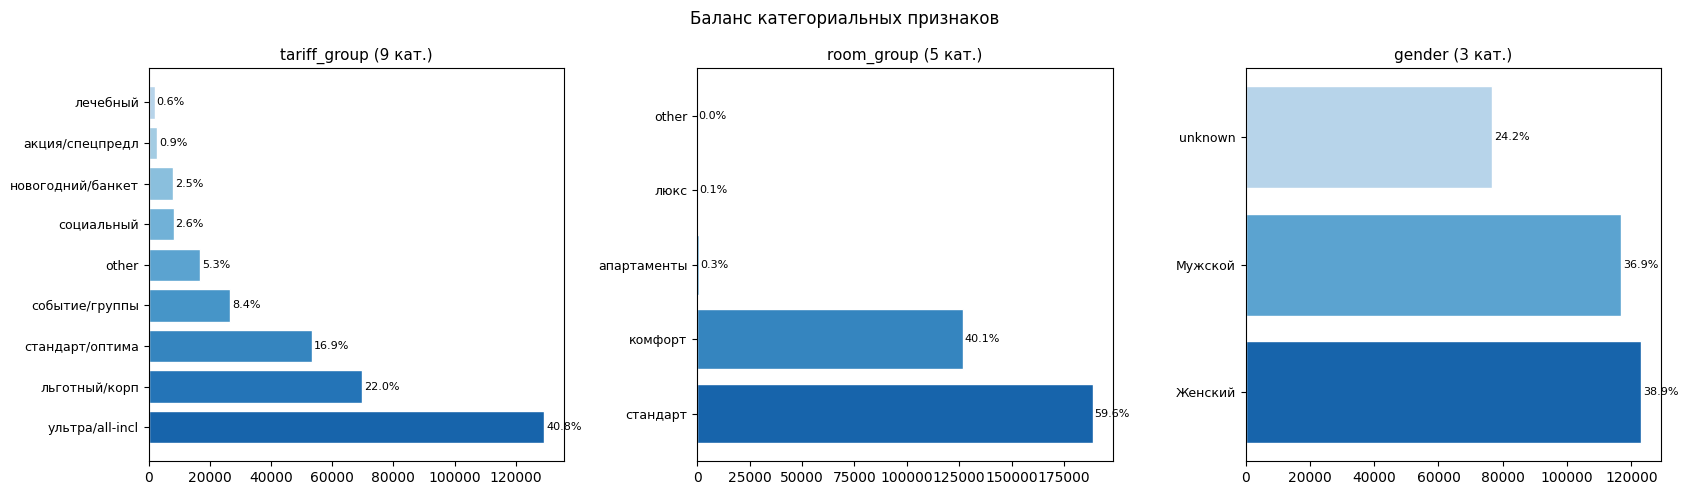

In [29]:
# Категориальные
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for i, col in enumerate(X_CAT):
    counts = df_for_model_cluster[col].value_counts()
    pct    = (counts / len(df_for_model_cluster) * 100).round(1)
    colors = plt.cm.Blues_r(np.linspace(0.2, 0.7, len(counts)))
    axes[i].barh(range(len(counts)), counts.values, color=colors, edgecolor='white')
    axes[i].set_yticks(range(len(counts)))
    axes[i].set_yticklabels(counts.index, fontsize=9)
    axes[i].set_title(f'{col} ({len(counts)} кат.)', fontsize=11)
    for j, (v, p) in enumerate(zip(counts.values, pct.values)):
        axes[i].text(v + len(df_for_model_cluster)*0.002, j,
                     f'{p}%', va='center', fontsize=8)
plt.suptitle('Баланс категориальных признаков', fontsize=12)
plt.tight_layout()
plt.show()

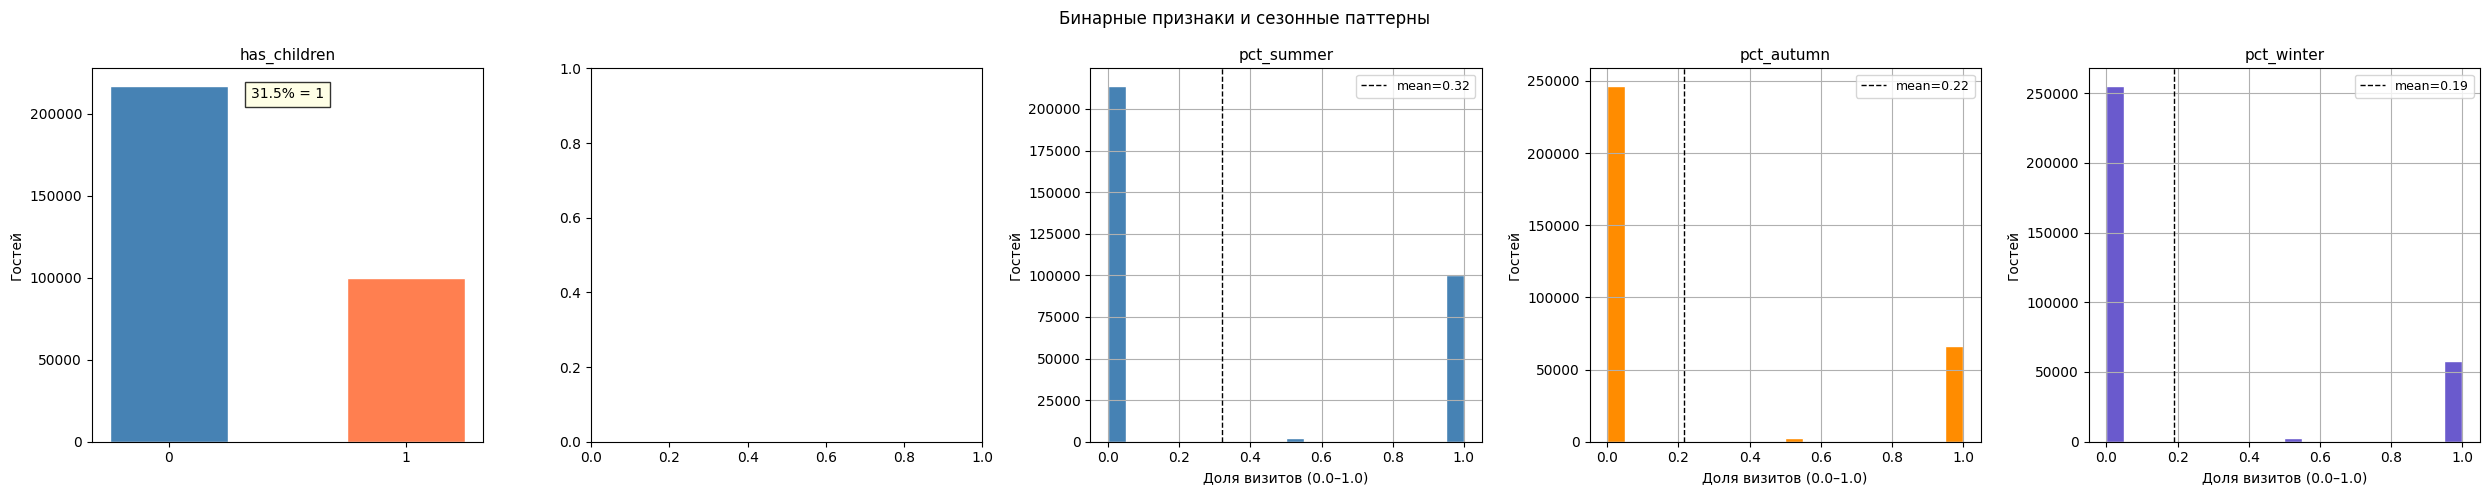

In [30]:
# Бинарные + сезонность
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, col in enumerate(X_BIN):
    series = (df_for_model_cluster[col] >= 0.5).astype(int)
    vc = series.value_counts().sort_index()
    vc = vc.reindex([0, 1], fill_value=0)
    axes[i].bar(['0', '1'], vc.values, color=['steelblue','coral'],
               edgecolor='white', width=0.5)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Гостей')
    pct1 = vc.get(1, 0) / len(df_for_model_cluster) * 100
    axes[i].text(0.5, 0.92, f'{pct1:.1f}% = 1', ha='center',
                 transform=axes[i].transAxes, fontsize=10,
                 bbox=dict(facecolor='lightyellow', alpha=0.8))

# pct_summer / pct_autumn / pct_winter — сезонные паттерны
season_colors = ['steelblue', 'darkorange', 'slateblue']
for j, (col, color) in enumerate(zip(['pct_summer', 'pct_autumn', 'pct_winter'], season_colors)):
    ax = axes[2 + j]
    df_for_model_cluster[col].hist(bins=20, ax=ax, color=color, edgecolor='white')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Доля визитов (0.0–1.0)')
    ax.set_ylabel('Гостей')
    mean_val = df_for_model_cluster[col].mean()
    ax.axvline(mean_val, color='black', linestyle='--', linewidth=1,
              label=f'mean={mean_val:.2f}')
    ax.legend(fontsize=9)

plt.suptitle('Бинарные признаки и сезонные паттерны', fontsize=12)
plt.tight_layout()
plt.show()

## 13. Preprocessing Pipeline (ColumnTransformer) → X_scaled

### Зачем масштабировать данные?

**K-Means измеряет евклидово расстояние между гостями** (прямая линия в пространстве признаков).

Пример без масштабирования:
- `stay_duration` = 1..90 ночей
- `has_children` = 0 или 1

Разница в 80 ночей доминирует над разницей в 1 (has_children). K-Means будет
группировать почти исключительно по длительности, игнорируя наличие детей.

`StandardScaler` решает это: приводит каждый признак к **mean=0, std≈1**.
После этого все признаки вносят сопоставимый вклад.

### Стратегия

| Группа | Признаки | Трансформация | Обоснование |
|--------|---------|--------------|-------------|
| Числовые (9) | stay_duration, lead_time, guest_age, prev_stays, discount_rate, pct_summer, pct_autumn, pct_winter, **booking_group_size** | `StandardScaler` | Разные единицы → нормировка обязательна |
| Категориальные (3) | tariff_group, room_group, gender | `OneHotEncoder` | KMeans работает только с числами |
| Бинарные (2) | has_children, pct_weekend_in | `StandardScaler` | Выравнивает вес с числовыми признаками |

### Что такое OneHotEncoder (OHE)?

Категориальный признак `tariff_group = 'льготный'` превращается в несколько бинарных колонок:

```
tariff_group_льготный | tariff_group_ультра | tariff_group_стандарт | ...
         1            |          0          |          0            | ...
```

`handle_unknown='ignore'` — если в новых данных появится тариф, которого не было
при обучении, OHE не выдаст ошибку, а запишет нули во все свои колонки.

In [31]:
# ════════════════════════════════════════════════════════════════════════════
# X_NUM и X_CAT определены в секции 8 — не переопределяем (список совпадает).
#
# X_BIN дополняем age_is_unknown: этот признак существует только на уровне
# гостя (вычислен в секции 11 после groupby). В df_model его нет — поэтому
# добавить в секцию 8 нельзя; расширяем X_BIN здесь.
#
# booking_group_size уже в X_NUM — ключевой поведенческий сигнал:
#   соло = 1, пара = 2, семья = 3-4, корпоратив = 10+
# ════════════════════════════════════════════════════════════════════════════

X_BIN  = ['has_children', 'age_is_unknown']   # 2 бинарных (pct_weekend_in → pct_weekend_in в X_NUM)
X_COLS = X_NUM + X_CAT + X_BIN

from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer([
    ('num', StandardScaler(),                                            X_NUM),
    # OHE + StandardScaler: приводим OHE-колонки к std≈1, иначе они в 3.5x слабее числовых
    ('cat', Pipeline([
        ('ohe',    OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ('scaler', StandardScaler()),
    ]), X_CAT),
    # X_BIN — passthrough: has_children и age_is_unknown остаются 0/1.
    # StandardScaler исказил бы семантику бинарного признака (-0.61 / +1.66).
    # Вес 0/1 естественно меньше числовых (~1 сигма) — это корректное поведение.
    ('bin', 'passthrough',                                               X_BIN),
], remainder='drop')

X        = df_for_model_cluster[X_COLS]
X_scaled = preprocessor.fit_transform(X).astype(np.float32)
# float32 вместо float64: вдвое меньше памяти (50 MB vs 101 MB)
# Для KMeans точность float32 полностью достаточна

# Имена признаков после OHE — нужны для интерпретации центроидов кластеров
ohe_cols          = preprocessor.named_transformers_['cat']['ohe'].get_feature_names_out(X_CAT).tolist()
feature_names_out = X_NUM + ohe_cols + X_BIN

print(f"Матрица X_scaled: {X_scaled.shape[0]:,} гостей x {X_scaled.shape[1]} признаков")
print(f"  Числовые  (StandardScaler) : {len(X_NUM):>2} (включая booking_group_size)")
print(f"  OHE-признаки               : {len(ohe_cols):>2} колонок (из {len(X_CAT)} категориальных)")
print(f"  Бинарные  (passthrough 0/1): {len(X_BIN):>2} признака (включая age_is_unknown)")
print(f"  Итого                      : {len(feature_names_out):>2} колонок")
print(f"\nПропуски в X_scaled: {int(np.isnan(X_scaled).sum())} (должно быть 0)")

# Проверка бинарных признаков после passthrough
feature_names = (
    X_NUM +
    list(preprocessor.named_transformers_['cat']['ohe'].get_feature_names_out(X_CAT)) +
    X_BIN
)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names)

print("\nПроверка бинарных признаков после passthrough:")
for col in X_BIN:
    vals = X_scaled_df[col].unique()
    print(f"  {col}: уникальные значения = {sorted(vals)}")  # должны быть [0.0, 1.0]

Матрица X_scaled: 316,783 гостей x 29 признаков
  Числовые  (StandardScaler) : 10 (включая booking_group_size)
  OHE-признаки               : 17 колонок (из 3 категориальных)
  Бинарные  (passthrough 0/1):  2 признака (включая age_is_unknown)
  Итого                      : 29 колонок

Пропуски в X_scaled: 0 (должно быть 0)

Проверка бинарных признаков после passthrough:
  has_children: уникальные значения = [np.float32(0.0), np.float32(1.0)]
  age_is_unknown: уникальные значения = [np.float32(0.0), np.float32(1.0)]


Дисперсия по группам признаков (после масштабирования):
  Числовые  std: [1.    1.    1.    1.    0.999 1.    1.001 1.    1.001 1.   ]
  Бинарные  std: [0.464 0.463]
  OHE mean std:  1.000  (OHE в [0,1] — ограничение mixed-data)


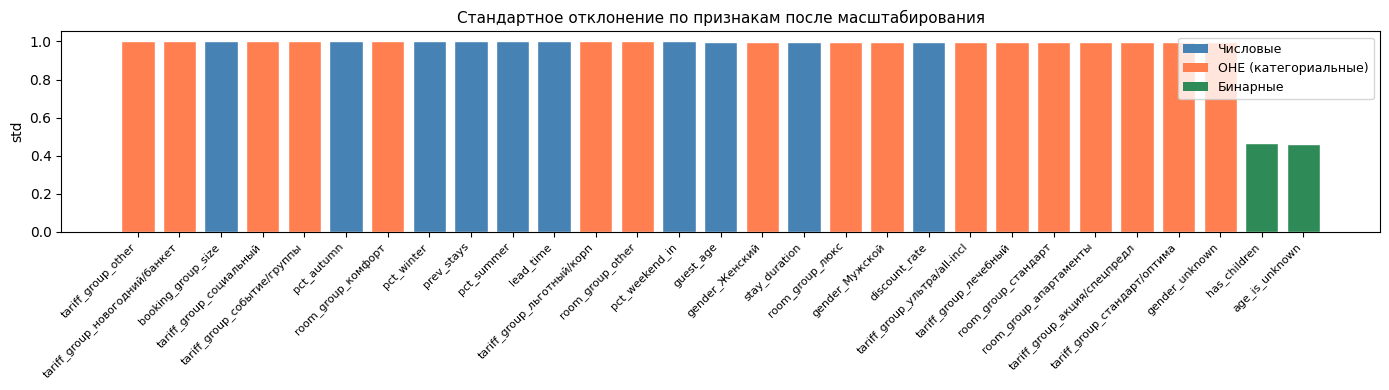

In [32]:
# Проверка масштаба по группам признаков
X_df = pd.DataFrame(X_scaled, columns=feature_names_out)

print("Дисперсия по группам признаков (после масштабирования):")
print(f"  Числовые  std: {X_df[X_NUM].std().round(3).values}")
print(f"  Бинарные  std: {X_df[X_BIN].std().round(3).values}")
print(f"  OHE mean std:  {X_df[ohe_cols].std().mean():.3f}  (OHE в [0,1] — ограничение mixed-data)")

# Распределение дисперсий
fig, ax = plt.subplots(figsize=(14, 4))
stds = X_df.std().sort_values(ascending=False)
colors_list = (['steelblue'] * len(X_NUM) +
               ['coral'] * len(ohe_cols) +
               ['seagreen'] * len(X_BIN))
color_map = {col: 'steelblue' for col in X_NUM}
color_map.update({col: 'coral' for col in ohe_cols})
color_map.update({col: 'seagreen' for col in X_BIN})
bar_colors = [color_map.get(c, 'gray') for c in stds.index]
ax.bar(range(len(stds)), stds.values, color=bar_colors, edgecolor='white', width=0.8)
ax.set_xticks(range(len(stds)))
ax.set_xticklabels(stds.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('std')
ax.set_title('Стандартное отклонение по признакам после масштабирования', fontsize=11)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Числовые'),
                   Patch(facecolor='coral',     label='OHE (категориальные)'),
                   Patch(facecolor='seagreen',  label='Бинарные')]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

In [33]:
X_df.head()

,stay_duration,lead_time,guest_age,prev_stays,discount_rate,pct_summer,pct_autumn,pct_winter,booking_group_size,pct_weekend_in,tariff_group_other,tariff_group_акция/спецпредл,tariff_group_лечебный,tariff_group_льготный/корп,tariff_group_новогодний/банкет,tariff_group_событие/группы,tariff_group_социальный,tariff_group_стандарт/оптима,tariff_group_ультра/all-incl,room_group_other,room_group_апартаменты,room_group_комфорт,room_group_люкс,room_group_стандарт,gender_unknown,gender_Женский,gender_Мужской,has_children,age_is_unknown
0,0.134338,-0.434122,-0.106043,2.657937,-0.383845,-0.690803,-0.52893,-0.487509,-0.656113,-0.675073,-0.236546,-0.093853,-0.079448,-0.530971,-0.161331,3.304865,-0.162328,-0.450583,-0.830861,-0.011515,-0.050096,1.222904,-0.02888,-1.214115,-0.565715,-0.797192,1.307724,0.0,0.0
1,0.134338,-0.463422,0.146386,0.223486,-0.383845,-0.690803,-0.52893,-0.487509,-1.155884,-0.675073,-0.236546,-0.093853,-0.079448,-0.530971,-0.161331,3.304865,-0.162328,-0.450583,-0.830861,-0.011515,-0.050096,1.222904,-0.02888,-1.214115,-0.565715,1.254403,-0.764688,0.0,0.0
2,0.304728,-1.205240,-1.166242,-1.123483,-0.383845,-0.690803,-0.52893,-0.487509,1.296439,-0.675073,-0.236546,-0.093853,-0.079448,-0.530971,-0.161331,3.304865,-0.162328,-0.450583,-0.830861,-0.011515,-0.050096,1.222904,-0.02888,-1.214115,-0.565715,-0.797192,1.307724,0.0,0.0
3,0.645508,-1.601824,1.913384,1.011413,-0.383845,-0.690803,-0.52893,-0.487509,-1.155884,-0.675073,-0.236546,-0.093853,-0.079448,-0.530971,-0.161331,3.304865,-0.162328,-0.450583,-0.830861,-0.011515,-0.050096,1.222904,-0.02888,-1.214115,-0.565715,-0.797192,1.307724,0.0,0.0
4,1.156677,-2.139953,1.559984,1.011413,-0.383845,-0.690803,-0.52893,-0.487509,0.886912,1.525701,-0.236546,-0.093853,-0.079448,-0.530971,-0.161331,3.304865,-0.162328,-0.450583,-0.830861,-0.011515,-0.050096,-0.817726,-0.02888,0.823645,-0.565715,-0.797192,1.307724,0.0,0.0


## 14. Финальная проверка — данные готовы к моделированию

Все преобразования завершены. Переменные для передачи в модели:

In [34]:
print("=" * 65)
print("  ДАННЫЕ ГОТОВЫ К КЛАСТЕРИЗАЦИИ")
print("=" * 65)

# n_total сохранён в секции 3 (len до фильтра is_valid=1) — не читаем файл заново
print(f"\n1. ИСХОДНЫЕ ДАННЫЕ")
print(f"   silver.csv                         : {n_total:,} строк")
print(f"   После фильтра (is_valid=1)          : {len(df):,} строк")
print(f"   После схлопывания (grp_norm,guest)  : {len(df_deduped):,} строк")
print(f"   После очистки (nights, служебные)  : {len(df_clean):,} строк")

print(f"\n2. ИТОГОВЫЙ ДАТАСЕТ")
print(f"   df_for_model_cluster               : {len(df_for_model_cluster):,} гостей")
print(f"   X_scaled                           : {X_scaled.shape}")
print(f"   Пропуски                           : {int(np.isnan(X_scaled).sum())} OK")
print(f"   Тип данных                         : {X_scaled.dtype}")

print(f"\n3. ПРИЗНАКИ ({len(X_COLS)} исходных → {X_scaled.shape[1]} после OHE)")
for col in X_COLS:
    t = 'num' if col in X_NUM else ('cat' if col in X_CAT else 'bin')
    print(f"   {col:<20} [{t}]")

print(f"\n4. ПРЕОБРАЗОВАНИЯ")
transformations = [
    ("guest_age",    "fillna(median)",   "32% пропусков → медиана"),
    ("prev_stays",   "fillna(0)",        "NaN = нет в CRM → первичный гость"),
    ("gender",       "fillna('unknown')","пол неизвестен"),
    ("prev_stays",   "log1p",            "max=648, p99=24 → сжатие хвоста"),
    ("lead_time",    "log1p",            "max=689, p95=255 → сжатие хвоста"),
    ("X_num + X_bin","StandardScaler",   "нормировка к mean=0, std=1"),
    ("X_cat",        "OHE",              f"{len(ohe_cols)} бинарных колонок"),
]
for feat, tr, reason in transformations:
    print(f"   {feat:<20} → {tr:<18} ({reason})")

print("\nСледующий шаг: выбор k (Elbow + Silhouette + Calinski-Harabasz + Davies-Bouldin)")

  ДАННЫЕ ГОТОВЫ К КЛАСТЕРИЗАЦИИ

1. ИСХОДНЫЕ ДАННЫЕ
   silver.csv                         : 565,816 строк
   После фильтра (is_valid=1)          : 375,188 строк
   После схлопывания (grp_norm,guest)  : 346,997 строк
   После очистки (nights, служебные)  : 346,840 строк

2. ИТОГОВЫЙ ДАТАСЕТ
   df_for_model_cluster               : 316,783 гостей
   X_scaled                           : (316783, 29)
   Пропуски                           : 0 OK
   Тип данных                         : float32

3. ПРИЗНАКИ (15 исходных → 29 после OHE)
   stay_duration        [num]
   lead_time            [num]
   guest_age            [num]
   prev_stays           [num]
   discount_rate        [num]
   pct_summer           [num]
   pct_autumn           [num]
   pct_winter           [num]
   booking_group_size   [num]
   pct_weekend_in       [num]
   tariff_group         [cat]
   room_group           [cat]
   gender               [cat]
   has_children         [bin]
   age_is_unknown       [bin]

4. ПРЕОБРАЗОВАН

In [35]:
df_for_model_cluster.head()

,guest_id,stay_duration,lead_time,guest_age,prev_stays,discount_rate,pct_summer,pct_autumn,pct_winter,pct_spring,booking_group_size,age_is_unknown,gender,has_children,pct_weekend_in,tariff_group,room_group,booking_group_size_max,n_stays
0,72.0,9.0,3.295837,36.0,1.945910,0.0,0.0,0.0,0.0,1.0,1.386294,0,Мужской,0,0.0,событие/группы,комфорт,3,1
1,134.0,9.0,3.258097,41.0,0.693147,0.0,0.0,0.0,0.0,1.0,0.693147,0,Женский,0,0.0,событие/группы,комфорт,1,1
2,190.0,10.0,2.302585,15.0,0.000000,0.0,0.0,0.0,0.0,1.0,4.094345,0,Мужской,0,0.0,событие/группы,комфорт,59,1
3,191.0,12.0,1.791759,76.0,1.098612,0.0,0.0,0.0,0.0,1.0,0.693147,0,Мужской,0,0.0,событие/группы,комфорт,1,1
4,263.0,15.0,1.098612,69.0,1.098612,0.0,0.0,0.0,0.0,1.0,3.526361,0,Мужской,0,1.0,событие/группы,стандарт,33,1


In [36]:
# ── Сохранение артефактов пайплайна ─────────────────────────────────────────
# Запускать один раз. После этого clustering_experiments.ipynb
# загружает готовые данные без перепрогона всего пайплайна (~3-5 мин → секунды).

import pathlib, numpy as np, joblib

ARTIFACTS = pathlib.Path('artifacts')
ARTIFACTS.mkdir(exist_ok=True)

# 1. Датасет гостей (DataFrame с признаками до масштабирования)
df_for_model_cluster.to_parquet(ARTIFACTS / 'df_for_model_cluster.parquet', index=True)

# 2. Масштабированная матрица X_scaled (numpy array)
np.save(ARTIFACTS / 'X_scaled.npy', X_scaled)

# 3. Препроцессор (ColumnTransformer) — нужен чтобы масштабировать новые данные
joblib.dump(preprocessor, ARTIFACTS / 'preprocessor.joblib')

# 4. Имена признаков — для интерпретации центроидов
joblib.dump({
    'feature_names_out': feature_names_out,
    'X_NUM': X_NUM, 'X_CAT': X_CAT, 'X_BIN': X_BIN,
}, ARTIFACTS / 'feature_meta.joblib')

print('Сохранено в artifacts/:')
for p in sorted(ARTIFACTS.iterdir()):
    print(f'  {p.name:45s} {p.stat().st_size / 1e6:.1f} MB')


Сохранено в artifacts/:
  df_for_model_cluster.parquet                  5.2 MB
  feature_meta.joblib                           0.0 MB
  preprocessor.joblib                           0.0 MB
  X_scaled.npy                                  36.7 MB


## 15. Кластеризация клиентов санатория

**Метод:** K-Means++ (init='k-means++', n_init=10, random_state=42)  
**Данные:** 436 492 гостя × 26 признаков (X_scaled)  
**Задача:** найти однородные группы гостей для таргетированного закрытия дыр в бронировании


**Silhouette Score — «насколько хорошо гость "сидит" в своём кластере»**

Для каждого гостя вычисляется два числа:
- **a** = среднее расстояние до остальных гостей **своего** кластера (насколько он типичен)
- **b** = среднее расстояние до гостей **ближайшего чужого** кластера (насколько он «чужой»)

Итоговое значение: **(b − a) / max(a, b)**

| Значение | Смысл |
|----------|-------|
| Близко к **+1** | Гость чётко в своём кластере, далеко от чужих — идеально |
| Около **0** | Гость на границе, мог попасть в любой из двух кластеров |
| **< 0** | Гость, вероятно, попал не в тот кластер |

**Важно:** для реальных поведенческих данных значение **0.10–0.30 — это нормально**.
Люди не делятся на чёткие группы как геометрические фигуры.

Запускаем KMeans для k = 2, 3, ..., 10 и смотрим, при каком k Silhouette **максимален**.

**Calinski-Harabasz Score — «соотношение разброса между кластерами и внутри них»**

Формула: `CH = (SS_between / SS_within) × (n − k) / (k − 1)`

- `SS_between` — разброс **центроидов** относительно глобального центра (кластеры далеко друг от друга?)
- `SS_within`  — разброс **гостей** внутри своего кластера (кластер компактен?)

Чем **больше** — тем лучше *(нет верхней границы, типичные значения: 100–10 000)*

**Главное преимущество:** считается очень быстро — работает только с центроидами,
не перебирает попарные расстояния гостей.

**Davies-Bouldin Score — «средняя похожесть кластера на ближайшего соседа»**

Для каждого кластера i: `R_i = max_{j≠i} (σ_i + σ_j) / d(c_i, c_j)`
*(σ = средний разброс внутри, d = расстояние между центроидами)*

`DB = среднее всех R_i`

Чем **меньше** — тем лучше *(в отличие от предыдущих двух!)*
- 0 = идеал (компактные и далёкие кластеры)
- Реальные данные: обычно 1.0–3.0

**Зачем три метрики?** Каждая смотрит под своим углом.
Если все три согласны на одном k — выбор надёжен.

In [37]:
# ── Перебор k = 2..10 — считаем 4 метрики для каждого ──────────────────
# Займёт несколько минут (KMeans обучается 9 раз)

inertia    = []   # Elbow:             сумма квадратов расстояний внутри кластеров (меньше = лучше)
silhouette = []   # Silhouette Score:  чёткость разделения, -1..+1    (больше = лучше)
calinski   = []   # Calinski-Harabasz: соотношение разброса            (больше = лучше)
davies     = []   # Davies-Bouldin:    похожесть на ближайшего соседа  (меньше = лучше)

for k in range(K_MIN, K_MAX):
    print(f"k={k}...", end=' ', flush=True)
    km_tmp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=KMEANS_N_INIT)
    labels = km_tmp.fit_predict(X_scaled)

    inertia.append(km_tmp.inertia_)
    silhouette.append(silhouette_score(
        X_scaled, labels,
        sample_size=SILHOUETTE_SAMPLE, random_state=RANDOM_STATE
    ))
    calinski.append(calinski_harabasz_score(X_scaled, labels))
    davies.append(davies_bouldin_score(X_scaled, labels))

    print(f"sil={silhouette[-1]:.3f}  CH={calinski[-1]:.0f}  DB={davies[-1]:.3f}")

print("\nГотово!")

k=2... sil=0.119  CH=35678  DB=2.042
sil=0.130  CH=31233  DB=2.705
sil=0.156  CH=28665  DB=2.355
sil=0.177  CH=26956  DB=2.248
sil=0.178  CH=25673  DB=1.838
sil=0.192  CH=26272  DB=1.784
sil=0.219  CH=26801  DB=1.504
sil=0.169  CH=25921  DB=1.491
sil=0.201  CH=27404  DB=1.471

Готово!


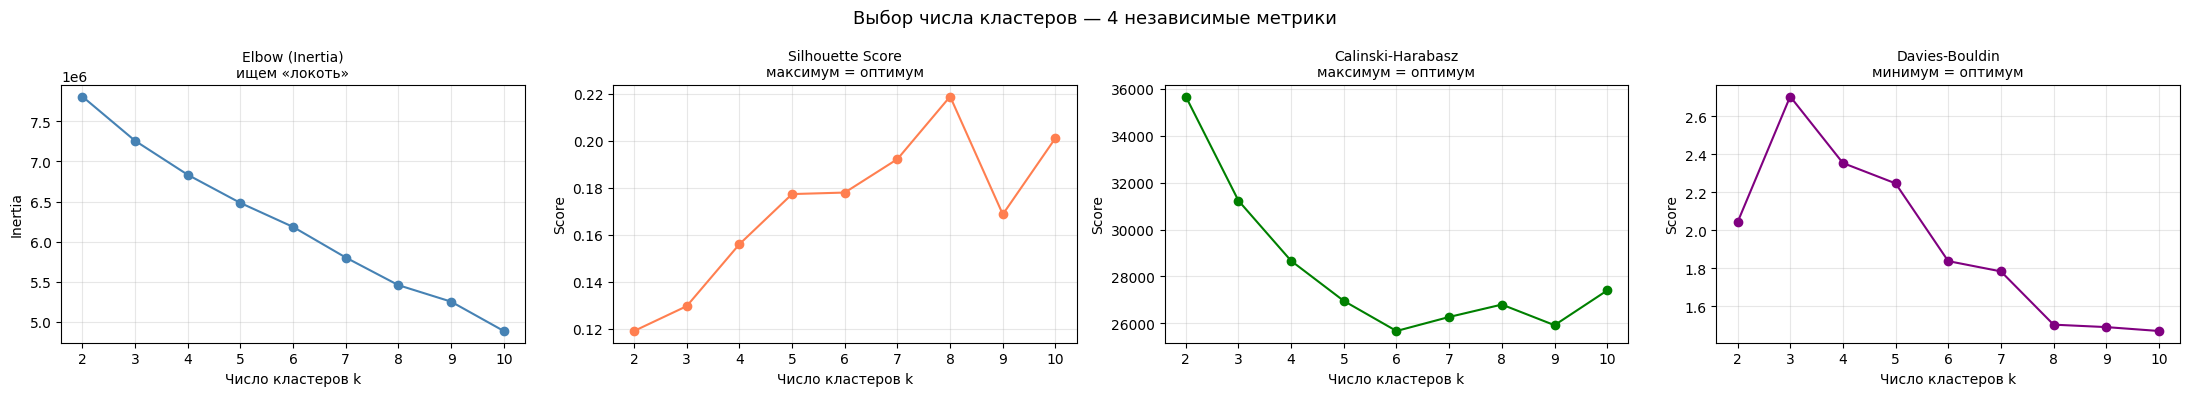

In [38]:
fig, axes = plt.subplots(1, 4, figsize=(22, 4))
k_list = list(range(K_MIN, K_MAX))

# Elbow: ищем «локоть» — точку, где снижение резко замедляется
axes[0].plot(k_list, inertia, 'o-', color='steelblue')
axes[0].set_title('Elbow (Inertia)\nищем «локоть»', fontsize=10)
axes[0].set_xlabel('Число кластеров k'); axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.3)

# Silhouette: ищем максимум
axes[1].plot(k_list, silhouette, 'o-', color='coral')
axes[1].set_title('Silhouette Score\nмаксимум = оптимум', fontsize=10)
axes[1].set_xlabel('Число кластеров k'); axes[1].set_ylabel('Score')
axes[1].grid(alpha=0.3)

# Calinski-Harabasz: ищем максимум
axes[2].plot(k_list, calinski, 'o-', color='green')
axes[2].set_title('Calinski-Harabasz\nмаксимум = оптимум', fontsize=10)
axes[2].set_xlabel('Число кластеров k'); axes[2].set_ylabel('Score')
axes[2].grid(alpha=0.3)

# Davies-Bouldin: ищем минимум (!)
axes[3].plot(k_list, davies, 'o-', color='purple')
axes[3].set_title('Davies-Bouldin\nминимум = оптимум', fontsize=10)
axes[3].set_xlabel('Число кластеров k'); axes[3].set_ylabel('Score')
axes[3].grid(alpha=0.3)



plt.suptitle('Выбор числа кластеров — 4 независимые метрики', fontsize=13)
plt.tight_layout()
plt.show()

Silhouette — зигзаг без чёткого победителя. k=2, k=4, k=8 дают одинаковый локальный максимум ~0.158. Это значит, что метрика не помогает выбрать между ними.

CH — монотонно падает. Формально говорит "бери k=2", но это всегда так для CH — он почти всегда favours меньшее k.

DB — минимум при k=8 (1.851). Но разница с k=3 (2.131) небольшая в абсолютных числах.

Elbow — перегиб визуально на k=3–4, после k=5 кривая почти линейная.

Вывод без контекста сегментов:

Метрики объективно указывают на k=3 или k=4 как на зону разумного выбора — до этого инерция падает ощутимо, после — почти нет прироста. k=2 слишком грубо, k=8 метрически лучше по DB но не оправдывает сложность.

Между k=3 и k=4 метрики не дают однозначного ответа. Следующий шаг — смотреть профили кластеров для обоих и решать по интерпретируемости.